### **DAY 1**

In [1]:
"""
DAY 1 - PRACTICE 1: Understanding Image Data
Goal: Learn how computers see images
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

#  1. CREATE A SIMPLE IMAGE 
print("\n1. Creating a simple 5x5 image...")

# Create a 5x5 image with random pixel values (0-255)
random_image = np.random.randint(0, 256, (5, 5, 3), dtype=np.uint8)
print(f"Image shape: {random_image.shape}")  # (height, width, channels)
print(f"First pixel (RGB): {random_image[0, 0]}")


1. Creating a simple 5x5 image...
Image shape: (5, 5, 3)
First pixel (RGB): [ 23 249 121]


In [3]:
#  2. UNDERSTAND CHANNELS 
print("\n2. Understanding RGB channels...")

# Create a red image
red_image = np.zeros((5, 5, 3), dtype=np.uint8)
red_image[:, :, 0] = 255 
print(f"Red pixel: {red_image[0, 0]}") 

# Create a green image
green_image = np.zeros((5, 5, 3), dtype=np.uint8)
green_image[:, :, 1] = 255 
print(f"Green pixel: {green_image[0, 0]}") 

# Create a blue image
blue_image = np.zeros((5, 5, 3), dtype=np.uint8)
blue_image[:, :, 2] = 255  
print(f"Blue pixel: {blue_image[0, 0]}") 


2. Understanding RGB channels...
Red pixel: [255   0   0]
Green pixel: [  0 255   0]
Blue pixel: [  0   0 255]


In [5]:
#  3. CONVERT TO PYTORCH TENSOR 
print("\n3. Converting to PyTorch tensor")

tensor_image = torch.from_numpy(random_image).permute(2, 0, 1).float() / 255.0
print(f"Tensor shape: {tensor_image.shape}")
print(f"Tensor values range: [{tensor_image.min():.2f}, {tensor_image.max():.2f}]")


3. Converting to PyTorch tensor
Tensor shape: torch.Size([3, 5, 5])
Tensor values range: [0.02, 1.00]



4. Visualizing images...


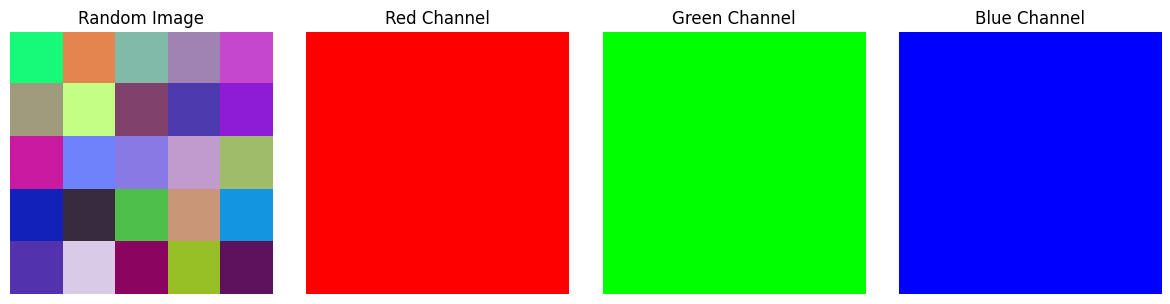

In [10]:
#  4. VISUALIZE IMAGE 
print("\n4. Visualizing images...")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Show random image
axes[0].imshow(random_image)
axes[0].set_title("Random Image")
axes[0].axis('off')

# Show red, green, blue images
axes[1].imshow(red_image)
axes[1].set_title("Red Channel")
axes[1].axis('off')

axes[2].imshow(green_image)
axes[2].set_title("Green Channel")
axes[2].axis('off')

axes[3].imshow(blue_image)
axes[3].set_title("Blue Channel")
axes[3].axis('off')

plt.tight_layout()
plt.savefig('day1_practice1_image_channels.png', dpi=150)
plt.show()

In [11]:
print("\n Practice 1 Complete!")
print("- Images are just grids of numbers")
print("- RGB = 3 channels (Red, Green, Blue)")
print("- PyTorch uses (C, H, W) format")


 Practice 1 Complete!
- Images are just grids of numbers
- RGB = 3 channels (Red, Green, Blue)
- PyTorch uses (C, H, W) format


In [12]:
"""
DAY 1 - PRACTICE 2: Understanding Convolution
Goal: Learn how convolution works step by step
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


#  1. MANUAL CONVOLUTION (STEP BY STEP) 
print("\n1. Manual convolution on a small image...")

# Create a simple 5x5 image
image = torch.tensor([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=torch.float32)

# Create a 3x3 filter (edge detector)
filter_kernel = torch.tensor([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
], dtype=torch.float32)

print("Original Image:")
print(image)
print("\nFilter (Edge Detector):")
print(filter_kernel)

# Manually apply convolution
def manual_conv2d(image, kernel):
    """Apply convolution manually"""
    h, w = image.shape
    k = kernel.shape[0]
    output_size = h - k + 1
    output = torch.zeros((output_size, output_size))
    
    for i in range(output_size):
        for j in range(output_size):
            # Extract region
            region = image[i:i+k, j:j+k]
            # Apply filter
            output[i, j] = (region * kernel).sum()
    
    return output

output = manual_conv2d(image, filter_kernel)
print("\nConvolution Output:")
print(output)


1. Manual convolution on a small image...
Original Image:
tensor([[ 1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10.],
        [11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20.],
        [21., 22., 23., 24., 25.]])

Filter (Edge Detector):
tensor([[-1., -1., -1.],
        [-1.,  8., -1.],
        [-1., -1., -1.]])

Convolution Output:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [13]:
#  2. PYTORCH CONVOLUTION 
print("\n2. Using PyTorch Conv2d...")

# Create Conv2d layer
conv_layer = nn.Conv2d(
    in_channels=1,    # Single channel (grayscale)
    out_channels=1,   # Single output channel
    kernel_size=3,    # 3x3 filter
    padding=0,        # No padding
    bias=False       # No bias for simplicity
)

# Set the weights to our filter
conv_layer.weight.data = filter_kernel.unsqueeze(0).unsqueeze(0)

# Add batch and channel dimensions: (batch, channel, height, width)
image_batch = image.unsqueeze(0).unsqueeze(0)
print(f"Image shape: {image_batch.shape}")  # (1, 1, 5, 5)

# Apply convolution
output_pytorch = conv_layer(image_batch)
print(f"Output shape: {output_pytorch.shape}")  # (1, 1, 3, 3)
print("PyTorch Convolution Output:")
print(output_pytorch.squeeze())


2. Using PyTorch Conv2d...
Image shape: torch.Size([1, 1, 5, 5])
Output shape: torch.Size([1, 1, 3, 3])
PyTorch Convolution Output:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<SqueezeBackward0>)



3. Visualizing convolution...


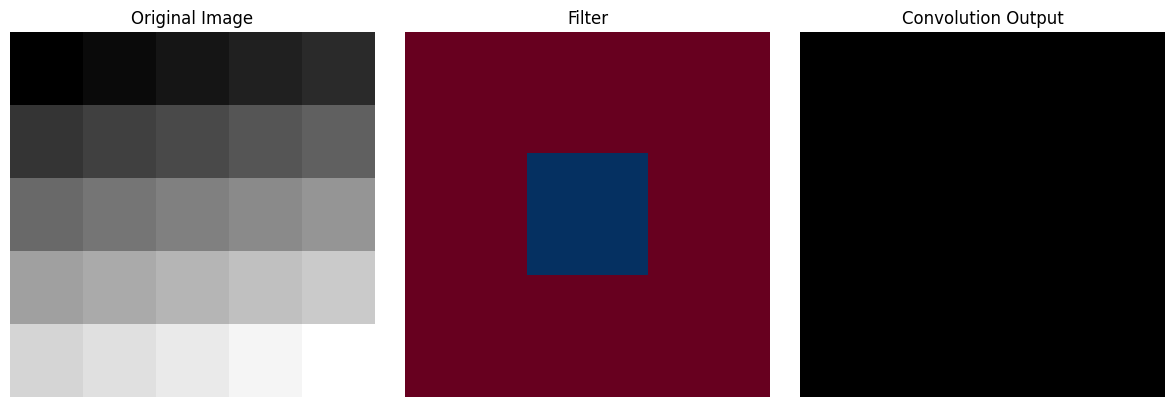


✅ Practice 2 Complete!
- Convolution multiplies filter with image regions
- Output size = Input - Filter + 1 (without padding)
- Filters learn to detect patterns


In [14]:
#  3. VISUALIZING CONVOLUTION 
print("\n3. Visualizing convolution...")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Show original image
axes[0].imshow(image.numpy(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Show filter
axes[1].imshow(filter_kernel.numpy(), cmap='RdBu')
axes[1].set_title("Filter")
axes[1].axis('off')

# Show output
axes[2].imshow(output.numpy(), cmap='gray')
axes[2].set_title("Convolution Output")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('day1_practice2_convolution.png', dpi=150)
plt.show()

print("\n✅ Practice 2 Complete!")
print("- Convolution multiplies filter with image regions")
print("- Output size = Input - Filter + 1 (without padding)")
print("- Filters learn to detect patterns")

In [15]:
#  4. TRY DIFFERENT PARAMETERS 
print("\n4. Trying different convolution parameters...")

# Different kernel sizes
conv_3x3 = nn.Conv2d(1, 1, kernel_size=3, padding=1)  # Same size output
conv_5x5 = nn.Conv2d(1, 1, kernel_size=5, padding=2)  # Same size output
conv_stride2 = nn.Conv2d(1, 1, kernel_size=3, stride=2)  # Smaller output

input_tensor = torch.randn(1, 1, 32, 32)

print(f"Input: {input_tensor.shape}")
print(f"3x3 with padding 1: {conv_3x3(input_tensor).shape}")
print(f"5x5 with padding 2: {conv_5x5(input_tensor).shape}")
print(f"3x3 with stride 2: {conv_stride2(input_tensor).shape}")


4. Trying different convolution parameters...
Input: torch.Size([1, 1, 32, 32])
3x3 with padding 1: torch.Size([1, 1, 32, 32])
5x5 with padding 2: torch.Size([1, 1, 32, 32])
3x3 with stride 2: torch.Size([1, 1, 15, 15])


In [16]:
"""
DAY 1 - PRACTICE 3: Building a Complete CNN
Goal: Create a working CNN from scratch
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


#  1. DEFINE CNN ARCHITECTURE 
print("\n1. Defining CNN architecture...")

class MyFirstCNN(nn.Module):
    """A simple CNN for MNIST classification"""
    
    def __init__(self):
        super(MyFirstCNN, self).__init__()
        
        # ============ CONVOLUTIONAL LAYERS ============
        # Layer 1: 1 input channel (grayscale) → 16 channels
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        # Layer 2: 16 → 32 channels
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        # Layer 3: 32 → 64 channels
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # ============ POOLING ============
        self.pool = nn.MaxPool2d(2, 2)
        
        # ============ FULLY CONNECTED LAYERS ============
        # After 3 pooling layers: 28 → 14 → 7 → 3
        # So: 64 * 3 * 3 = 576
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes (digits 0-9)
        
        # ============ REGULARIZATION ============
        self.dropout = nn.Dropout(0.5)
        
        # ============ ACTIVATION ============
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Input: (batch, 1, 28, 28)
        
        # Block 1: Conv → BN → ReLU → Pool
        x = self.conv1(x)           # (batch, 16, 28, 28)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)            # (batch, 16, 14, 14)
        
        # Block 2: Conv → BN → ReLU → Pool
        x = self.conv2(x)           # (batch, 32, 14, 14)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)            # (batch, 32, 7, 7)
        
        # Block 3: Conv → BN → ReLU → Pool
        x = self.conv3(x)           # (batch, 64, 7, 7)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)            # (batch, 64, 3, 3)
        
        # Flatten
        x = x.view(x.size(0), -1)   # (batch, 64*3*3=576)
        
        # Fully connected layers
        x = self.fc1(x)             # (batch, 128)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)             # (batch, 10)
        
        return x

# Create model
model = MyFirstCNN()
print("Model created successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


1. Defining CNN architecture...
Model created successfully!
Total parameters: 98,666


In [17]:
#  2. UNDERSTAND LAYER SIZES 
print("\n2. Understanding layer sizes...")

# Create a sample input
sample_input = torch.randn(1, 1, 28, 28)
print(f"Input shape: {sample_input.shape}")

# Forward pass
with torch.no_grad():
    output = model(sample_input)
print(f"Output shape: {output.shape}")


2. Understanding layer sizes...
Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])


In [18]:
#  3. LOAD MNIST DATA 
print("\n3. Loading MNIST data...")

# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load training data
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test data
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


3. Loading MNIST data...


100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.8MB/s]

Training samples: 60000
Test samples: 10000



4. Visualizing sample MNIST images...


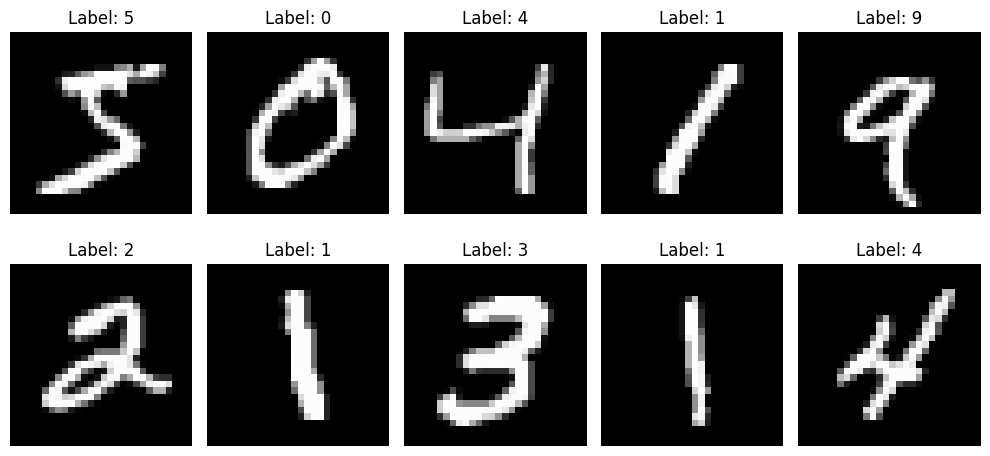

In [19]:
#  4. SHOW SAMPLE IMAGES 
print("\n4. Visualizing sample MNIST images...")

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    img, label = train_dataset[i]
    axes[i//5, i%5].imshow(img.squeeze(), cmap='gray')
    axes[i//5, i%5].set_title(f"Label: {label}")
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.savefig('day1_practice3_mnist_samples.png', dpi=150)
plt.show()

In [20]:
#  5. TRAIN THE MODEL 
print("\n5. Training the model...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 100 == 99:
            avg_loss = running_loss / 100
            train_losses.append(avg_loss)
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Loss: {avg_loss:.4f}")
            running_loss = 0.0


5. Training the model...
Epoch 1, Batch 100, Loss: 0.8246
Epoch 1, Batch 200, Loss: 0.2136
Epoch 1, Batch 300, Loss: 0.1527
Epoch 1, Batch 400, Loss: 0.1284
Epoch 1, Batch 500, Loss: 0.1398
Epoch 1, Batch 600, Loss: 0.0912
Epoch 1, Batch 700, Loss: 0.0960
Epoch 1, Batch 800, Loss: 0.0919
Epoch 1, Batch 900, Loss: 0.0847
Epoch 2, Batch 100, Loss: 0.0749
Epoch 2, Batch 200, Loss: 0.0731
Epoch 2, Batch 300, Loss: 0.0652
Epoch 2, Batch 400, Loss: 0.0807
Epoch 2, Batch 500, Loss: 0.0677
Epoch 2, Batch 600, Loss: 0.0685
Epoch 2, Batch 700, Loss: 0.0702
Epoch 2, Batch 800, Loss: 0.0650
Epoch 2, Batch 900, Loss: 0.0539
Epoch 3, Batch 100, Loss: 0.0543
Epoch 3, Batch 200, Loss: 0.0555
Epoch 3, Batch 300, Loss: 0.0568
Epoch 3, Batch 400, Loss: 0.0529
Epoch 3, Batch 500, Loss: 0.0494
Epoch 3, Batch 600, Loss: 0.0560
Epoch 3, Batch 700, Loss: 0.0491
Epoch 3, Batch 800, Loss: 0.0545
Epoch 3, Batch 900, Loss: 0.0439


In [21]:
#  6. EVALUATE MODEL 
print("\n6. Evaluating model...")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


6. Evaluating model...
Test Accuracy: 98.93%



7. Showing predictions...


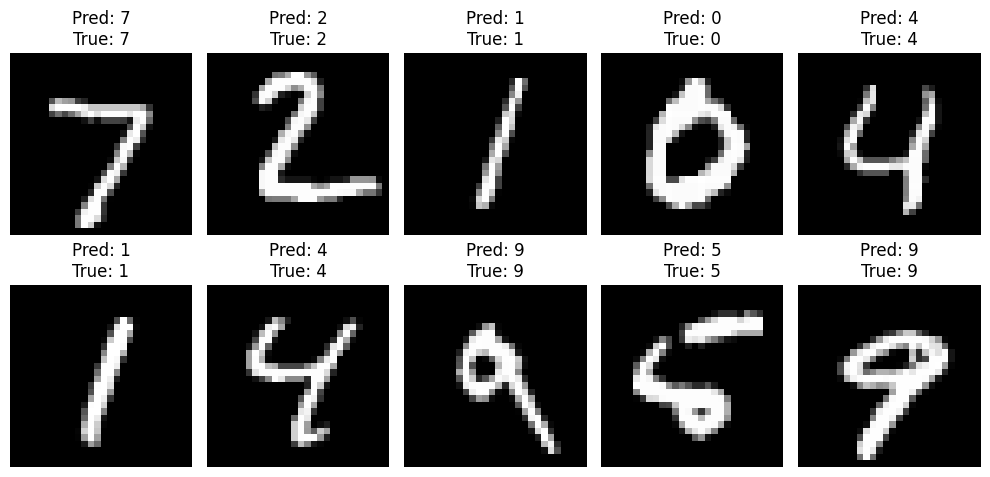


✅ DAY 1 COMPLETE!
- Learned about image data representation
- Understood convolution operation
- Built a complete CNN from scratch
- Trained on MNIST dataset
- Achieved good accuracy!


In [22]:
#  7. SHOW PREDICTIONS 
print("\n7. Showing predictions...")

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    img, label = test_dataset[i]
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
    
    axes[i//5, i%5].imshow(img.squeeze(), cmap='gray')
    axes[i//5, i%5].set_title(f"Pred: {predicted.item()}\nTrue: {label}")
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.savefig('day1_practice3_predictions.png', dpi=150)
plt.show()

print("\n✅ DAY 1 COMPLETE!")
print("- Learned about image data representation")
print("- Understood convolution operation")
print("- Built a complete CNN from scratch")
print("- Trained on MNIST dataset")
print("- Achieved good accuracy!")